# Preforming a Exploratory Data Analysis on the Teleco data

Goal: find which customer characteristics are associated with churn.

This notebook reads the cleaned data from `data/processed` (see [data-cleaning](data-cleaning.ipynb))

In [2]:
import sys 
# Adding the local path to the notebook so it can use the utils written locally.
sys.path.append("..")

from source.helpers import churn_rate_by

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/teleco-churn-data-cleaned.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
overall_rate = df["Churn"].eq("Yes").mean() * 100
f"Overall rate: {overall_rate.round(1)}"

'Overall rate: 26.5'

## 1. Distribution of the numeric columns

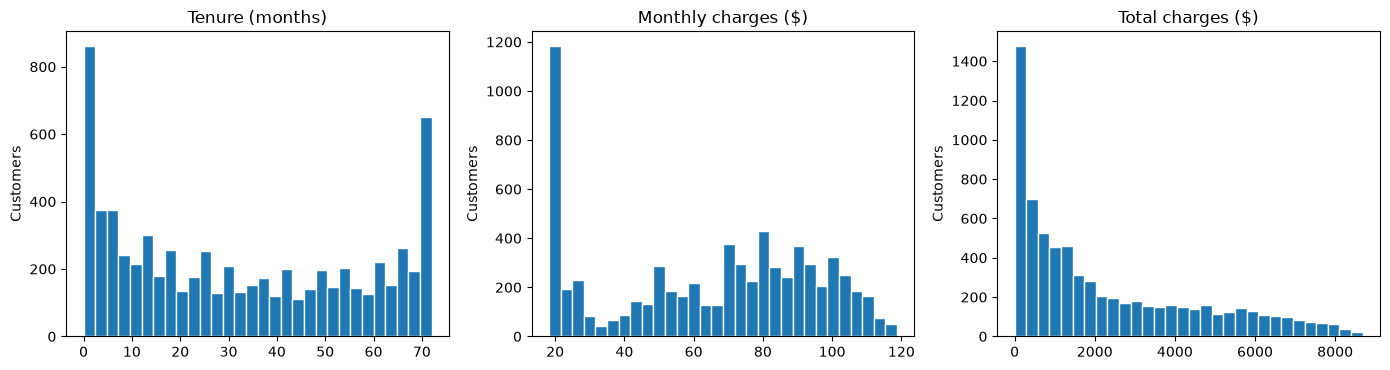

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

for ax, col, title in zip(
    axes,
    ["tenure", "MonthlyCharges", "TotalCharges"],
    ["Tenure (months)", "Monthly charges ($)", "Total charges ($)"],
):
    ax.hist(df[col], bins=30, color="tab:blue", edgecolor="white")
    ax.set_title(title)
    ax.set_ylabel("Customers")

plt.tight_layout()
plt.show()


In [6]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe().round(1)

,tenure,MonthlyCharges,TotalCharges
count,7043.0,7043.0,7043.0
mean,32.4,64.8,2279.7
std,24.6,30.1,2266.8
min,0.0,18.2,0.0
25%,9.0,35.5,398.6
50%,29.0,70.4,1394.6
75%,55.0,89.8,3786.6
max,72.0,118.8,8684.8


- **Tenure** has two peaks: many customers are new (31% have 12 months or less) and many are long-term (20% have 61 months or more). There are fewer in between.

- **MonthlyCharges** has a large cluster at the low end, and wide spread above 70.

- **TotalCharges** is right-skewed, whitch is expected because it accumlates with tenure.

## 2. Demographics

In [7]:
from source.helpers import plot_churn_rate

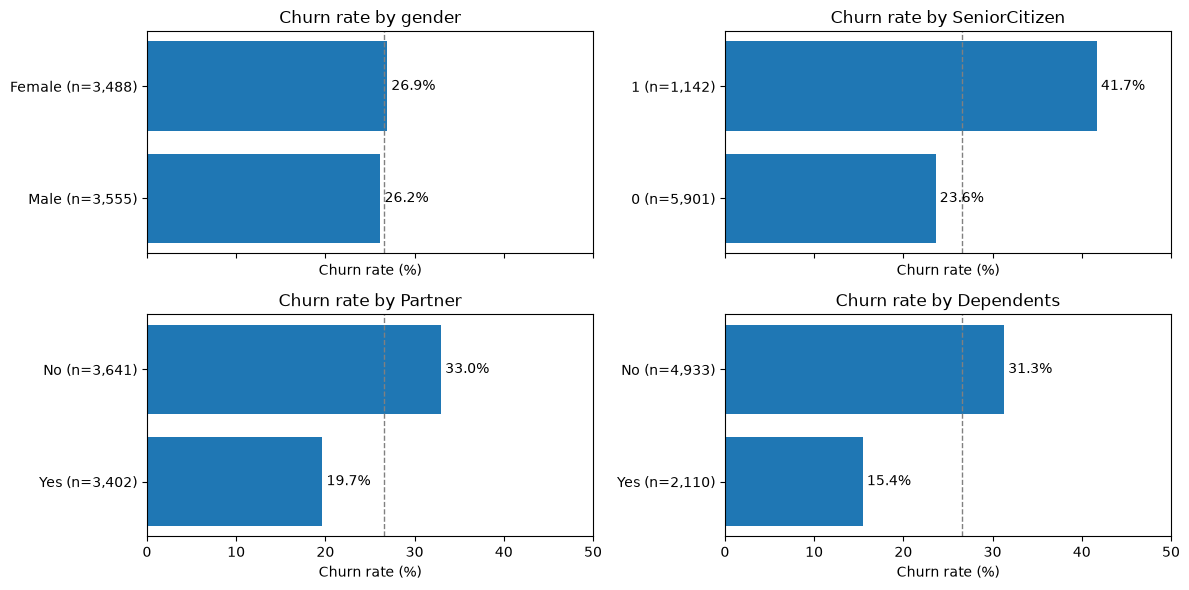

In [8]:
demographic_cols = ["gender", "SeniorCitizen", "Partner", "Dependents"]


fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)

for ax, col in zip(axes.ravel(), demographic_cols):
    title = f"Churn rate by {col}"
    plot_churn_rate(churn_rate_by(df, col), title, ax=ax, baseline=overall_rate)

plt.tight_layout()
plt.show()

- **Gender**: no meaningful differene (26.9% vs 26.2%)

- **Senior citizen**: Churn at 41.7% vs 23.6%, so part of the gap may come from the contract type.

- **Partner / Dependents**: customers without a partner churn at 33.0% (vs 19.7%), and without dependents at 31.3% (vs 15.5%). Customers with a family tend to stay.

## 3. Services

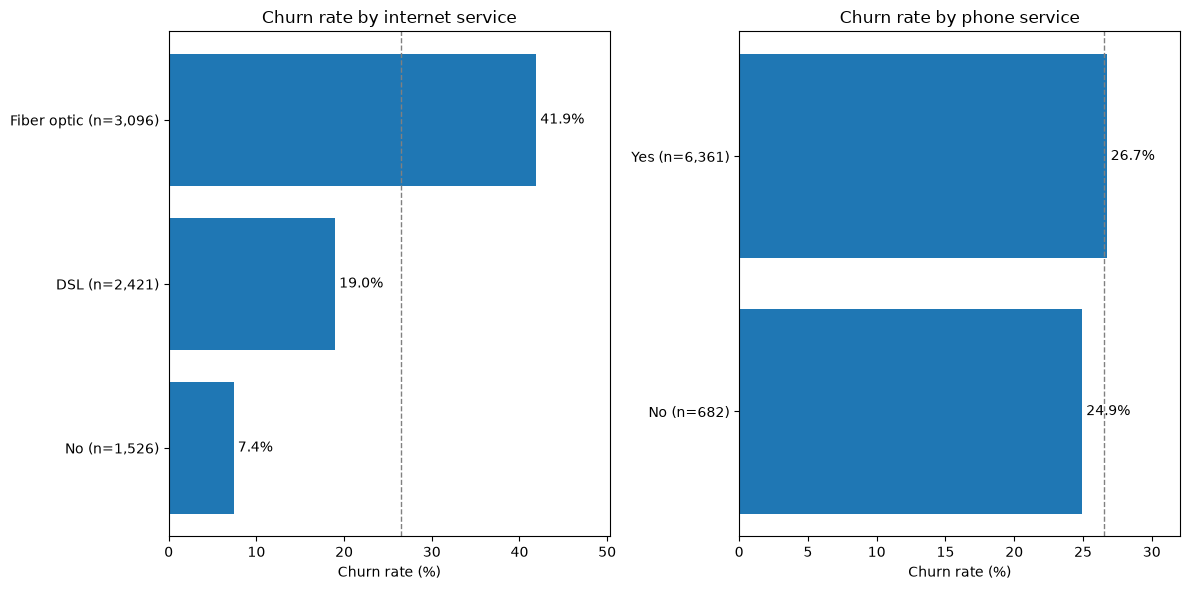

InternetService
DSL            58.1
Fiber optic    91.5
No             21.1
Name: MonthlyCharges, dtype: float64

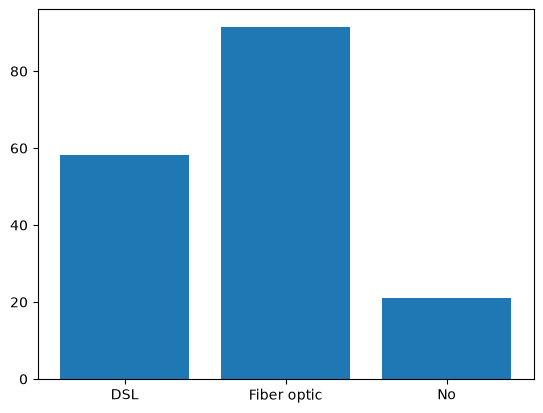

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

plot_churn_rate(
    churn_rate_by(df, "InternetService"), "Churn rate by internet service", axes[0], baseline=overall_rate)

plot_churn_rate(
    churn_rate_by(df, "PhoneService"), "Churn rate by phone service", ax=axes[1], baseline=overall_rate)

plt.tight_layout()
plt.show()

internetServicePay = df.groupby("InternetService")["MonthlyCharges"].mean().round(1)
plt.bar(internetServicePay.index, internetServicePay)
internetServicePay

### 3.1. Add-on services

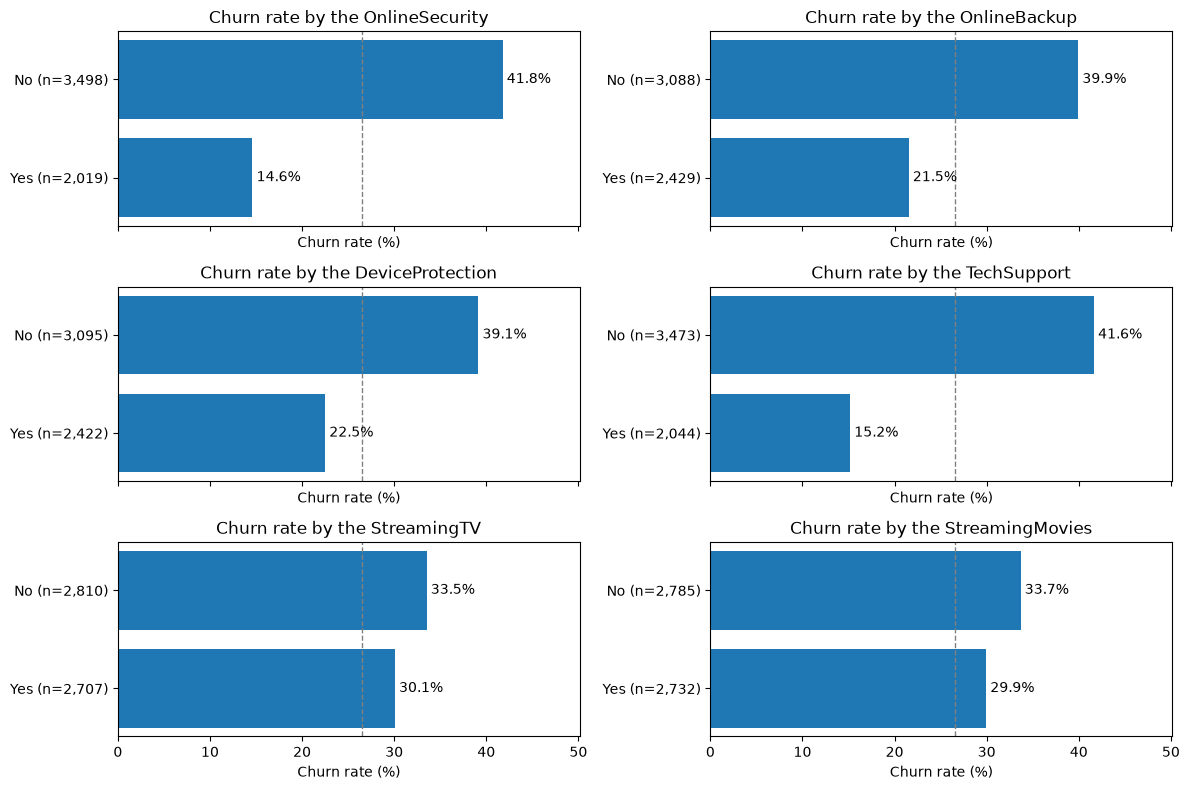

In [10]:
internet = df[df["InternetService"] != "No"]
addons = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"]

fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True)

for ax, service in zip(axes.ravel(), addons):
    title = f"Churn rate by the {service}"
    summery = churn_rate_by(internet, service)
    plot_churn_rate(summary=summery, title=title, ax=ax, baseline=overall_rate, sort=False)
plt.tight_layout()
plt.show()

- `Customers` without OnlineSecurity churn at 41.8% vs 14.6% with it. For `TechSupport` it is 41.6% vs 15.2%.
- `OnlineBackup` and `DeviceProtection` show a smaller gap (about 40% vs 22%).
- **Streaming** services show only a weak difference (about 30% vs 34%)

## 4. Tenure

In [11]:
from source.helpers import tenureSegments


df = tenureSegments(df)
df.groupby("tenure_segment")["customerID"].count()

tenure_segment
0-12     2186
13-24    1024
25-48    1594
49-72    2239
Name: customerID, dtype: int64

In [12]:
churn_rate_by(df, "tenure_segment")

,customers,churn_rate_pct
tenure_segment,,
0-12,2186,47.44
13-24,1024,28.71
25-48,1594,20.39
49-72,2239,9.51


<Axes: title={'center': 'Churn rate by tenure'}, xlabel='Churn rate (%)'>

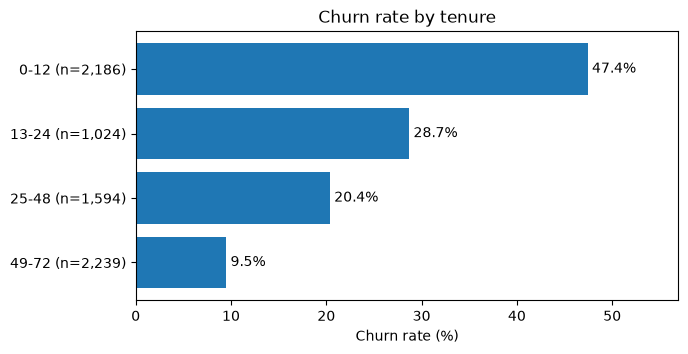

In [13]:
plot_churn_rate(churn_rate_by(df, "tenure_segment"), "Churn rate by tenure")

As the figure shows above, 47.4% of customers churn with their first year.